# **בדיקת חיבור לשרת ומעבד**

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # המשך רק אם התקבל 1 או יותר

TensorFlow Version: 2.14.0
Num GPUs Available:  1


# **ייבוא ספריות**

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


# **ווידוא זיכרון בשרת**

In [ ]:
# הגדרת ניהול זיכרון GPU למניעת שגיאות OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled!")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled!


# **נתיבים והגדרות**

In [ ]:
# --- הגדרת נתיבים (מצביעים לתיקייה בשרת של רופין) ---
BASE_DIR = "/users/amit.cohen/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **חלוקה לגנרטורים - אימון \ אימות**

In [ ]:
# גנרטור לאימון (עם אוגמנטציה)

# === הגדרת הגנרטורים והאוגמנטציה (Data Augmentation) ===
# המטרה: מניעת Overfitting (שינון) ע"י יצירת וריאציות של התמונות "תוך כדי תנועה" (On-the-fly).
# בכל Epoch, הגנרטור מחליף את התמונה המקורית בגרסה מעובדת, כך שהמודל לעולם לא רואה את אותה תמונה פעמיים בדיוק.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,           # עיוות מינימלי
    zoom_range=0.05,            # זום מינימלי למניעת חיתוך
    horizontal_flip=True,
    fill_mode='nearest'
)

# גנרטור לוולידציה (בלי אוגמנטציה, רק rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# טעינה
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, # נתיב ישיר לתיקיית ה-Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # כדי למנוע מהמודל ללמוד את סדר הנתונים ולהבטיח גיוון בכל באץ
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, # נתיב ישיר לתיקיית ה-Val
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"המחלקות שזוהו: {class_names}")

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
המחלקות שזוהו: ['Black&White', 'Cartoon', 'Good', 'Multiple', 'Noise or blur', 'Sketch', 'Text', 'Toys']


# **Fine-Tuning Block5 using best configuration**

In [ ]:
# הגדרת נתיבים יחסיים לשרת (מותאם לשמירה מההרצה הקודמת)
PREV_MODEL_PATH = "final_best_vgg16_model.h5"
FINETUNED_MODEL_PATH = "final_best_vgg16_finetuned.h5"

# פרמטרים ל-Fine Tuning
FINE_TUNE_LR = 1e-5
EPOCHS_FT = 25

print(f"Loading the best model from previous step: {PREV_MODEL_PATH}...")
try:
    model = load_model(PREV_MODEL_PATH)
    print("Model loaded successfully.")
except OSError:
    print(f"Error: Could not find {PREV_MODEL_PATH}. Check your current working directory.")

# הגדרת הקפאה/הפשרה של שכבות
print("Configuring layers for Fine-Tuning...")

for layer in model.layers:
    # בלוקים 1-4: הקפאה (זיהוי מאפיינים בסיסיים של התמונה)
    if layer.name.startswith(('block1', 'block2', 'block3', 'block4')):
        layer.trainable = False

    # בלוק 5: הפשרה (התאמת זיהוי אובייקטים מורכבים לדאטהסט שלנו)
    elif layer.name.startswith('block5'):
        layer.trainable = True

    # שכבות סיווג מותאמות (Head): פתוחות לאימון
    elif layer.name in ['final_dense_layer', 'dropout', 'prediction']:
        layer.trainable = True

# אימות והדפסת השכבות הפעילות
print("\nActive Trainable Layers:")
for layer in model.layers:
    if layer.trainable and len(layer.weights) > 0:
        print(f"🔓 {layer.name}")

# קימפול מחדש - LR נמוך במיוחד למניעת דריסת משקולות קיימות (Catastrophic forgetting)
print(f"\nRe-compiling model with Learning Rate: {FINE_TUNE_LR}")
model.compile(optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# הגדרת Callbacks
checkpoint_ft = ModelCheckpoint(
    FINETUNED_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# הרצת האימון
print("Starting Fine-Tuning process...")
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    callbacks=[early_stop_ft, checkpoint_ft]
)

Loading the best model from previous step: final_best_vgg16_model.h5...


2026-04-08 19:38:21.289233: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20285 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0


Model loaded successfully.
Configuring layers for Fine-Tuning...

Active Trainable Layers:
🔓 block5_conv1
🔓 block5_conv2
🔓 block5_conv3
🔓 final_dense_layer
🔓 prediction

Re-compiling model with Learning Rate: 1e-05
Starting Fine-Tuning process...
Epoch 1/25


2026-04-08 19:38:26.274749: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-04-08 19:38:29.368791: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-08 19:38:34.083700: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-08 19:38:34.798088: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f7ceadfbe10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-08 19:38:34.798111: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-04-08 19:38:34.803907: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-08 19:38:34.975443: I ./tensorflow/compiler/jit/device_compil

21/21 [==============================] - ETA: 0s - loss: 0.2285 - accuracy: 0.9182
Epoch 1: val_accuracy improved from -inf to 0.88194, saving model to final_best_vgg16_finetuned.h5


/users/amit.cohen/.local/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


21/21 [==============================] - 26s 551ms/step - loss: 0.2285 - accuracy: 0.9182 - val_loss: 0.4194 - val_accuracy: 0.8819
Epoch 2/25
21/21 [==============================] - ETA: 0s - loss: 0.1854 - accuracy: 0.9435
Epoch 2: val_accuracy improved from 0.88194 to 0.90278, saving model to final_best_vgg16_finetuned.h5
21/21 [==============================] - 11s 510ms/step - loss: 0.1854 - accuracy: 0.9435 - val_loss: 0.3664 - val_accuracy: 0.9028
Epoch 3/25
21/21 [==============================] - ETA: 0s - loss: 0.1421 - accuracy: 0.9658
Epoch 3: val_accuracy did not improve from 0.90278
21/21 [==============================] - 10s 491ms/step - loss: 0.1421 - accuracy: 0.9658 - val_loss: 0.3566 - val_accuracy: 0.9028
Epoch 4/25
21/21 [==============================] - ETA: 0s - loss: 0.1543 - accuracy: 0.9449
Epoch 4: val_accuracy did not improve from 0.90278
21/21 [==============================] - 10s 485ms/step - loss: 0.1543 - accuracy: 0.9449 - val_loss: 0.3969 - val_acc

# **Loading FT-MODEL**

In [ ]:
# הנתיב המקומי בשרת (כפי שהוגדר ונשמר בבלוק האימון)
model_path = "final_best_vgg16_finetuned.h5"

# --- מנגנון בטיחות: בודק אם כבר הרצנו את האימון ושמרנו את המודל ---
if os.path.exists(model_path):
    model = load_model(model_path)
    print(f"המודל '{model_path}' נטען בהצלחה! מוכן להמשך עבודה.")
else:
    print(f"שגיאה: הקובץ '{model_path}' לא נמצא. ודא שבלוק ה-Fine-Tuning סיים לרוץ בהצלחה ונשמר בתיקייה הנוכחית.")

# **Visualization**


=== Fine-Tuning Results ===
Best Epoch (Auto-detected): 17
Final Training Accuracy: 0.9807
Final Validation Accuracy: 0.9028
Final Training Loss: 0.0606
Final Validation Loss: 0.3237



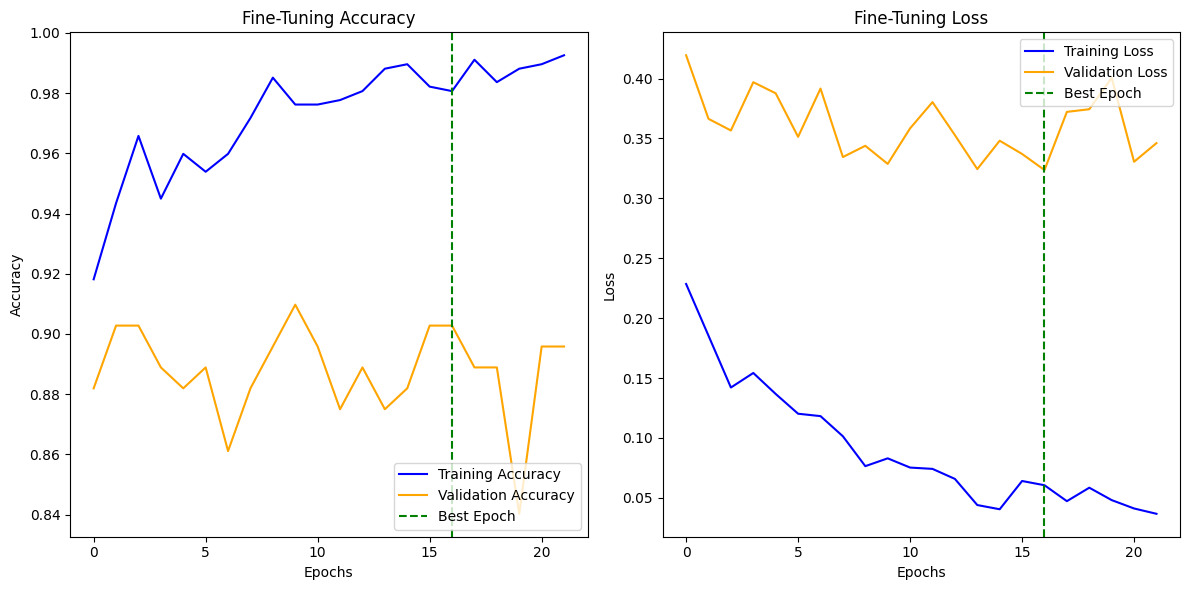

In [ ]:
# חילוץ הנתונים מההיסטוריה של אימון ה-Fine Tuning
acc = history_ft.history['accuracy']
val_acc = history_ft.history['val_accuracy']
loss = history_ft.history['loss']
val_loss = history_ft.history['val_loss']

# --- זיהוי אוטומטי של האפוק הטוב ביותר ---
# ה-EarlyStopping שלנו עוקב אחרי 'val_loss', לכן נחפש את האינדקס שבו ה-val_loss היה הנמוך ביותר
best_epoch_idx = np.argmin(val_loss)

print("\n=== Fine-Tuning Results ===")
print(f"Best Epoch (Auto-detected): {best_epoch_idx + 1}")
print(f"Final Training Accuracy: {acc[best_epoch_idx]:.4f}")
print(f"Final Validation Accuracy: {val_acc[best_epoch_idx]:.4f}")
print(f"Final Training Loss: {loss[best_epoch_idx]:.4f}")
print(f"Final Validation Loss: {val_loss[best_epoch_idx]:.4f}")
print("===========================\n")

# יצירת הגרפים
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 1. גרף דיוק (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
# סימון הנקודה הטובה ביותר על הגרף
plt.axvline(x=best_epoch_idx, color='green', linestyle='--', label='Best Epoch')
plt.legend(loc='lower right')
plt.title('Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# 2. גרף שגיאה (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
# סימון הנקודה הטובה ביותר על הגרף
plt.axvline(x=best_epoch_idx, color='green', linestyle='--', label='Best Epoch')
plt.legend(loc='upper right')
plt.title('Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# הצגת הגרפים
plt.tight_layout()
plt.show()

# **שילוב אימון + אימות**

In [ ]:
import random

# נתיבים (בשרת)
PREV_MODEL_PATH = "final_best_vgg16_finetuned.h5"
FINAL_COMBINED_MODEL_PATH = "final_best_vgg16_combined_data.h5"

print(f"Loading model from server: {PREV_MODEL_PATH}...")
model = load_model(PREV_MODEL_PATH)

# --- השדרוג שלך: החלת אוגמנטציה גם על תמונות הוולידציה ---
print("Preparing Validation data with Training Augmentations...")
# אנחנו משתמשים ב-train_datagen המקורי מהמחברת שלך, אבל מכוונים אותו לתיקיית ה-VAL!
val_gen_augmented = train_datagen.flow_from_directory(
    VAL_DIR, # ודא שהמשתנה VAL_DIR מוגדר למעלה עם הנתיב הנכון
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # חובה לשנות ל-True כי עכשיו זה חלק מהאימון!
)

# --- פונקציית איחוד On The Fly ---
def combined_generator(train_gen, val_gen_aug):
    # חישוב ההסתברות למשוך מסט האימון לעומת הוולידציה
    p_train = len(train_gen) / (len(train_gen) + len(val_gen_aug))

    while True:
        if random.random() < p_train:
            yield next(train_gen)
        else:
            yield next(val_gen_aug)

# סך כל הצעדים באפוק שווה לסכום הצעדים של שני הגנרטורים
total_steps_per_epoch = len(train_gen) + len(val_gen_augmented)

# הגדרת שמירת המודל - הפעם עוקבים אחרי דיוק האימון
checkpoint_combined = ModelCheckpoint(
    FINAL_COMBINED_MODEL_PATH,
    monitor='accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print(f"\nStarting ON-THE-FLY training on FULLY AUGMENTED Combined Data for {best_epoch_idx+1} epochs...")
history_combined = model.fit(
    combined_generator(train_gen, val_gen_augmented), # מעבירים את הגנרטור המשודרג (עם אוגמנטציה)
    steps_per_epoch=total_steps_per_epoch,
    epochs=best_epoch_idx+1,
    callbacks=[checkpoint_combined]
)

print(f"\nFinished! The ultimate combined model is saved locally as: {FINAL_COMBINED_MODEL_PATH}")

Loading model from server: final_best_vgg16_finetuned.h5...
Preparing Validation data with Training Augmentations...
Found 144 images belonging to 8 classes.

Starting ON-THE-FLY training on FULLY AUGMENTED Combined Data for 17 epochs...
Epoch 1/17
26/26 [==============================] - ETA: 0s - loss: 0.1526 - accuracy: 0.9485
Epoch 1: accuracy improved from -inf to 0.94853, saving model to final_best_vgg16_combined_data.h5


/users/amit.cohen/.local/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


26/26 [==============================] - 11s 387ms/step - loss: 0.1526 - accuracy: 0.9485
Epoch 2/17
26/26 [==============================] - ETA: 0s - loss: 0.1763 - accuracy: 0.9449
Epoch 2: accuracy did not improve from 0.94853
26/26 [==============================] - 11s 421ms/step - loss: 0.1763 - accuracy: 0.9449
Epoch 3/17
26/26 [==============================] - ETA: 0s - loss: 0.1058 - accuracy: 0.9694
Epoch 3: accuracy improved from 0.94853 to 0.96936, saving model to final_best_vgg16_combined_data.h5
26/26 [==============================] - 11s 425ms/step - loss: 0.1058 - accuracy: 0.9694
Epoch 4/17
26/26 [==============================] - ETA: 0s - loss: 0.0814 - accuracy: 0.9755
Epoch 4: accuracy improved from 0.96936 to 0.97549, saving model to final_best_vgg16_combined_data.h5
26/26 [==============================] - 11s 420ms/step - loss: 0.0814 - accuracy: 0.9755
Epoch 5/17
26/26 [==============================] - ETA: 0s - loss: 0.1073 - accuracy: 0.9645
Epoch 5: accu

# **תוצאות**

In [ ]:
# הגדרת גנרטור לטסט (רק נרמול, בלי אוגמנטציות)
test_datagen = ImageDataGenerator(rescale=1./255)

print("\nLoading Test Images...")
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False # קריטי למטריצת הבלבול
)


Loading Test Images...
Found 144 images belonging to 8 classes.


נערך חיזוי על סט הטסט...
5/5 [==============================] - 1s 127ms/step


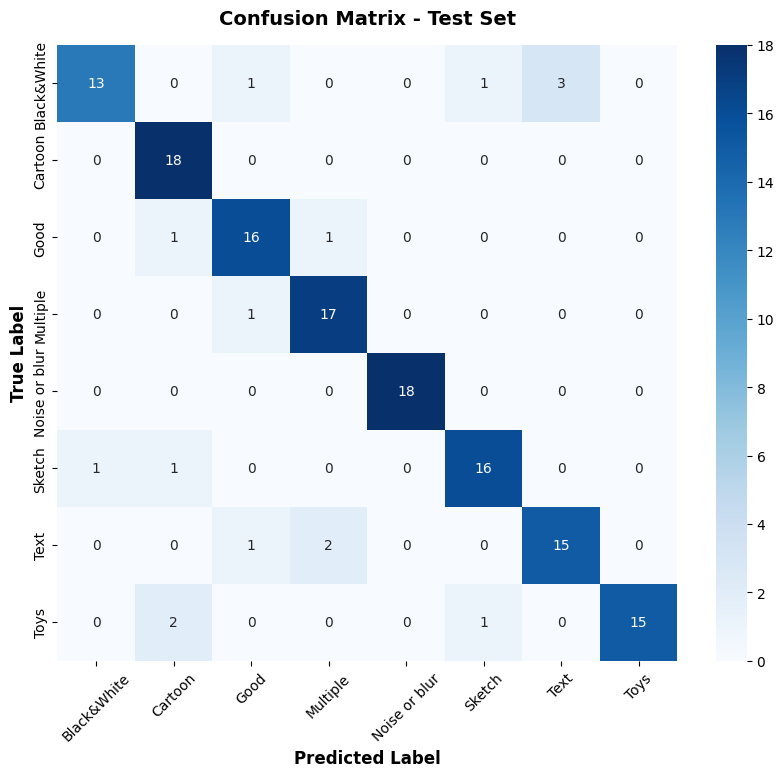


דיוק כללי במבחן האמת (Test Accuracy): 88.89%

Classification Report:

               precision    recall  f1-score   support

  Black&White       0.93      0.72      0.81        18
      Cartoon       0.82      1.00      0.90        18
         Good       0.84      0.89      0.86        18
     Multiple       0.85      0.94      0.89        18
Noise or blur       1.00      1.00      1.00        18
       Sketch       0.89      0.89      0.89        18
         Text       0.83      0.83      0.83        18
         Toys       1.00      0.83      0.91        18

     accuracy                           0.89       144
    macro avg       0.90      0.89      0.89       144
 weighted avg       0.90      0.89      0.89       144



In [ ]:
# חילוץ שמות המחלקות ישירות מהגנרטור של הטסט כדי למנוע שגיאות משתנים חסרים
class_names = list(test_gen.class_indices.keys())

# 1. ביצוע חיזוי על כל סט הטסט
print("נערך חיזוי על סט הטסט...")
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1) # הפיכת הסתברויות למספר מחלקה (0, 1, 2...)
y_true = test_gen.classes # התוויות האמיתיות

# 2. יצירת מטריצת הבלבול
cm = confusion_matrix(y_true, y_pred)

# 3. ציור הגרף
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.show()

# 4. חישוב והדפסת הדיוק הכללי (התוספת החדשה!)
accuracy = accuracy_score(y_true, y_pred)
print("\n" + "="*45)
print(f"דיוק כללי במבחן האמת (Test Accuracy): {accuracy * 100:.2f}%")
print("="*45 + "\n")

# 5. דוח טקסטואלי מפורט
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

מכין תצוגות חזותיות של החיזויים (כולל Top 3 Softmax)...



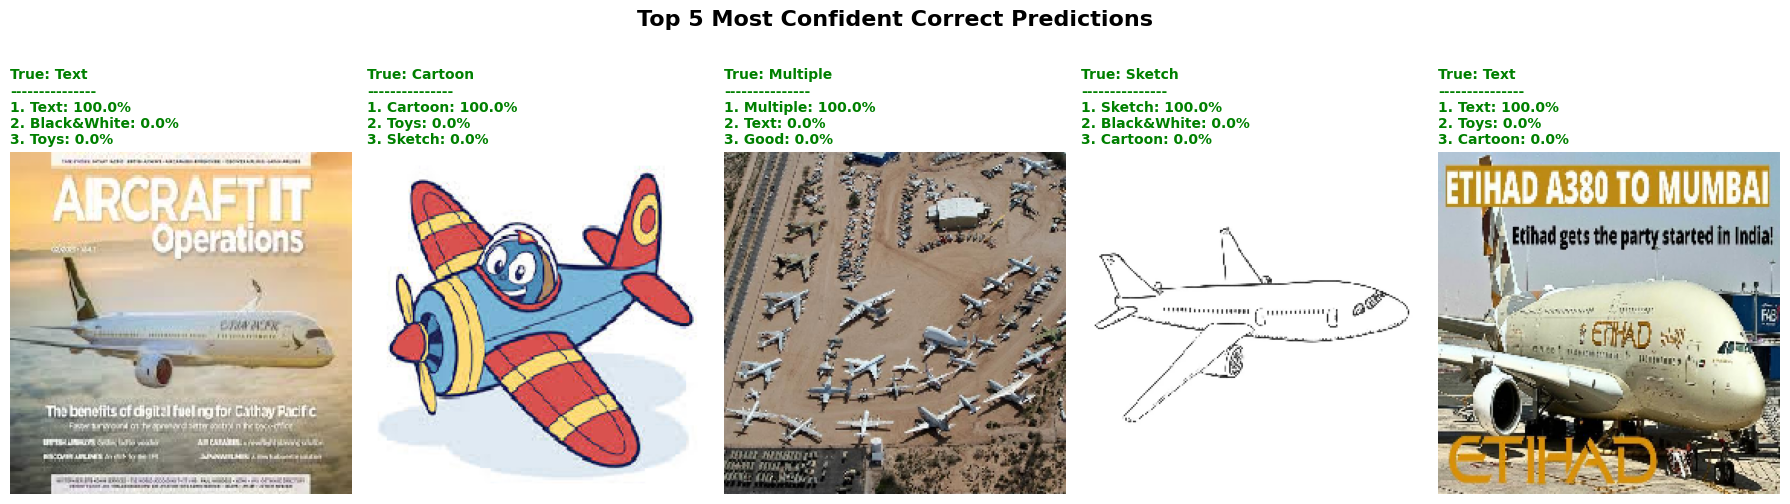

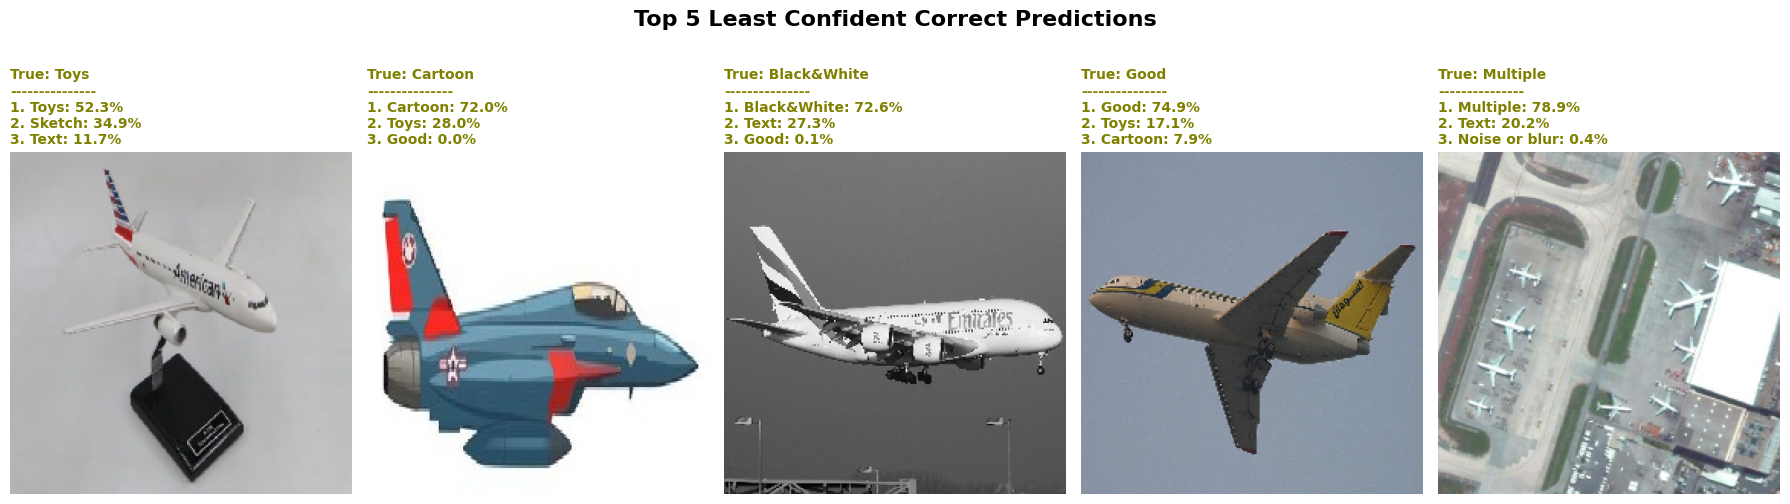

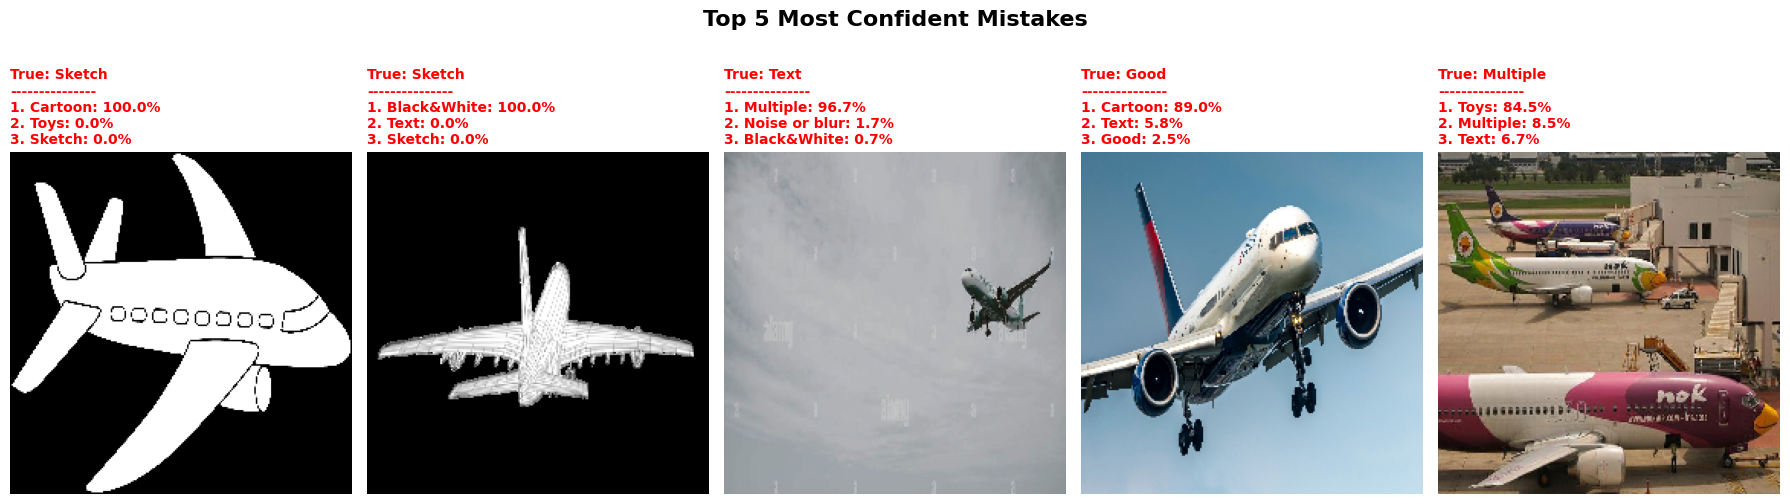

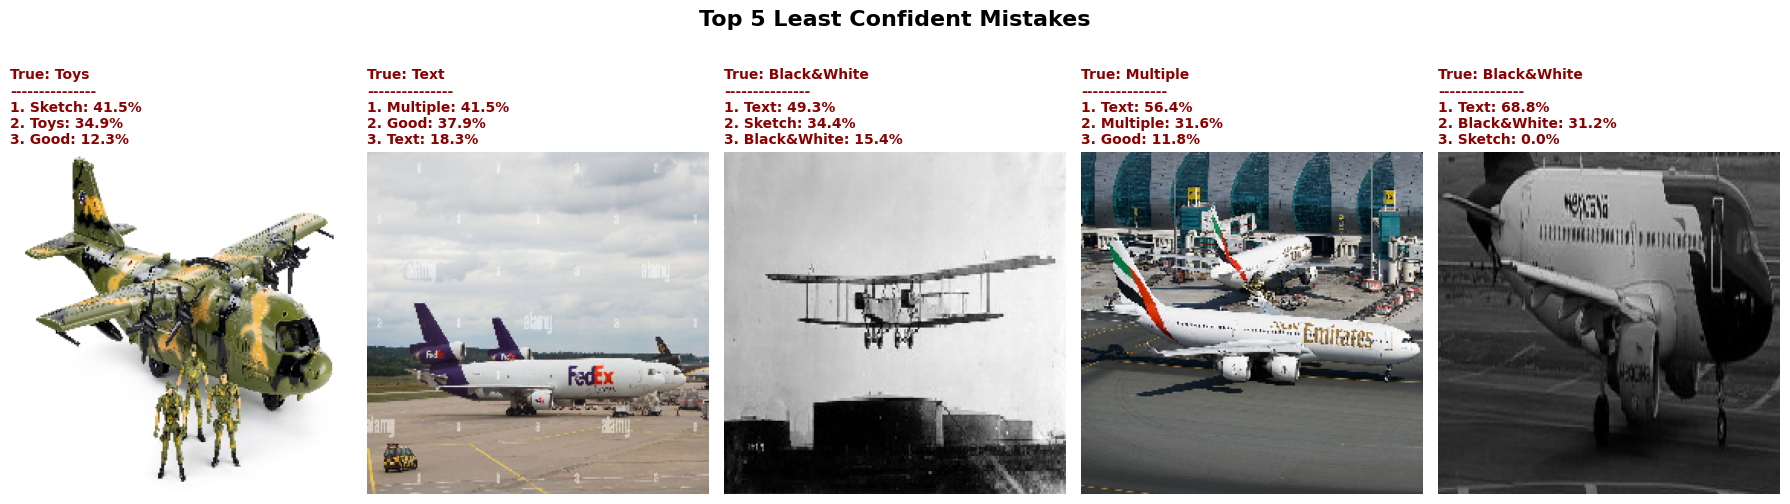

In [ ]:
from tensorflow.keras.preprocessing import image

# --- 5. הצגת הצלחות וכישלונות כולל התפלגות 3 התחזיות המובילות ---

# שליפת רשימת הקבצים
file_paths = test_gen.filepaths

# מציאת אינדקסים
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# שליפת רמות הביטחון (Confidence) של התחזית המובילה (לצורך מיון)
confidences = np.max(y_pred_prob, axis=1)

def plot_sorted_predictions(indices, title, color, sort_descending=True):
    if len(indices) == 0:
        print(f"\nלא נמצאו דוגמאות עבור: {title}")
        return

    # הגדלנו את הגרף קצת כדי שיהיה מקום לטקסט הארוך יותר
    plt.figure(figsize=(18, 5))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.08)

    # שולפים את הביטחון רק עבור האינדקסים הרלוונטיים
    relevant_confidences = confidences[indices]

    # מיון האינדקסים (Argsort)
    if sort_descending:
        # מהגבוה לנמוך (הכי בטוחים)
        sorted_order = np.argsort(relevant_confidences)[::-1]
    else:
        # מהנמוך לגבוה (הכי פחות בטוחים)
        sorted_order = np.argsort(relevant_confidences)

    # לוקחים את ה-5 הראשונים אחרי המיון (או פחות אם אין 5)
    n_show = min(5, len(indices))
    top_n_indices = indices[sorted_order[:n_show]]

    for i, idx in enumerate(top_n_indices):
        img_path = file_paths[idx]
        img = image.load_img(img_path, target_size=(224, 224))

        true_label = class_names[y_true[idx]]

        # --- חילוץ 3 התחזיות המובילות (Top 3) מתוך ה-Softmax ---
        sample_probs = y_pred_prob[idx]
        top_3_indices = np.argsort(sample_probs)[::-1][:3] # אינדקסים של 3 הגבוהים ביותר

        # בניית טקסט להצגה
        text_display = f"True: {true_label}\n"
        text_display += "-" * 15 + "\n"
        for rank, c_idx in enumerate(top_3_indices):
            pred_class_name = class_names[c_idx]
            pred_prob = sample_probs[c_idx] * 100
            text_display += f"{rank+1}. {pred_class_name}: {pred_prob:.1f}%\n"

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        # מציגים את הטקסט. הקטנתי טיפה פונט כדי שיכנס יפה
        plt.title(text_display.strip(), color=color, fontsize=10, fontweight='bold', loc='left')

    plt.tight_layout()
    plt.show()

# --- הפעלת הפונקציות ---

print("מכין תצוגות חזותיות של החיזויים (כולל Top 3 Softmax)...\n")

# 1. ההצלחות הכי גדולות (המודל צדק והיה בטוח בעצמו)
plot_sorted_predictions(correct_indices, "Top 5 Most Confident Correct Predictions", 'green', sort_descending=True)

# 2. ההצלחות הכי "חלשות" (המודל צדק, אבל בקושי - היסס בין מחלקות)
plot_sorted_predictions(correct_indices, "Top 5 Least Confident Correct Predictions", 'olive', sort_descending=False)

if len(incorrect_indices) > 0:
    # 3. הטעויות הכי "קשות" (המודל היה בטוח שהוא צודק, אבל טעה לחלוטין!)
    plot_sorted_predictions(incorrect_indices, "Top 5 Most Confident Mistakes", 'red', sort_descending=True)

    # 4. הטעויות הכי "מהססות" (המודל טעה, אבל גם לא היה בטוח בעצמו)
    plot_sorted_predictions(incorrect_indices, "Top 5 Least Confident Mistakes", 'darkred', sort_descending=False)
else:
    print("\nאין טעויות להציג - המודל הגיע ל-100% דיוק!")

# **נסיון להגדיל אחוזי דיוק**

מגדיר אוגמנטציה אגרסיבית למניעת התאמת יתר (Overfitting)...

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

מציג דוגמאות של אוגמנטציה (3 מכל מחלקה):


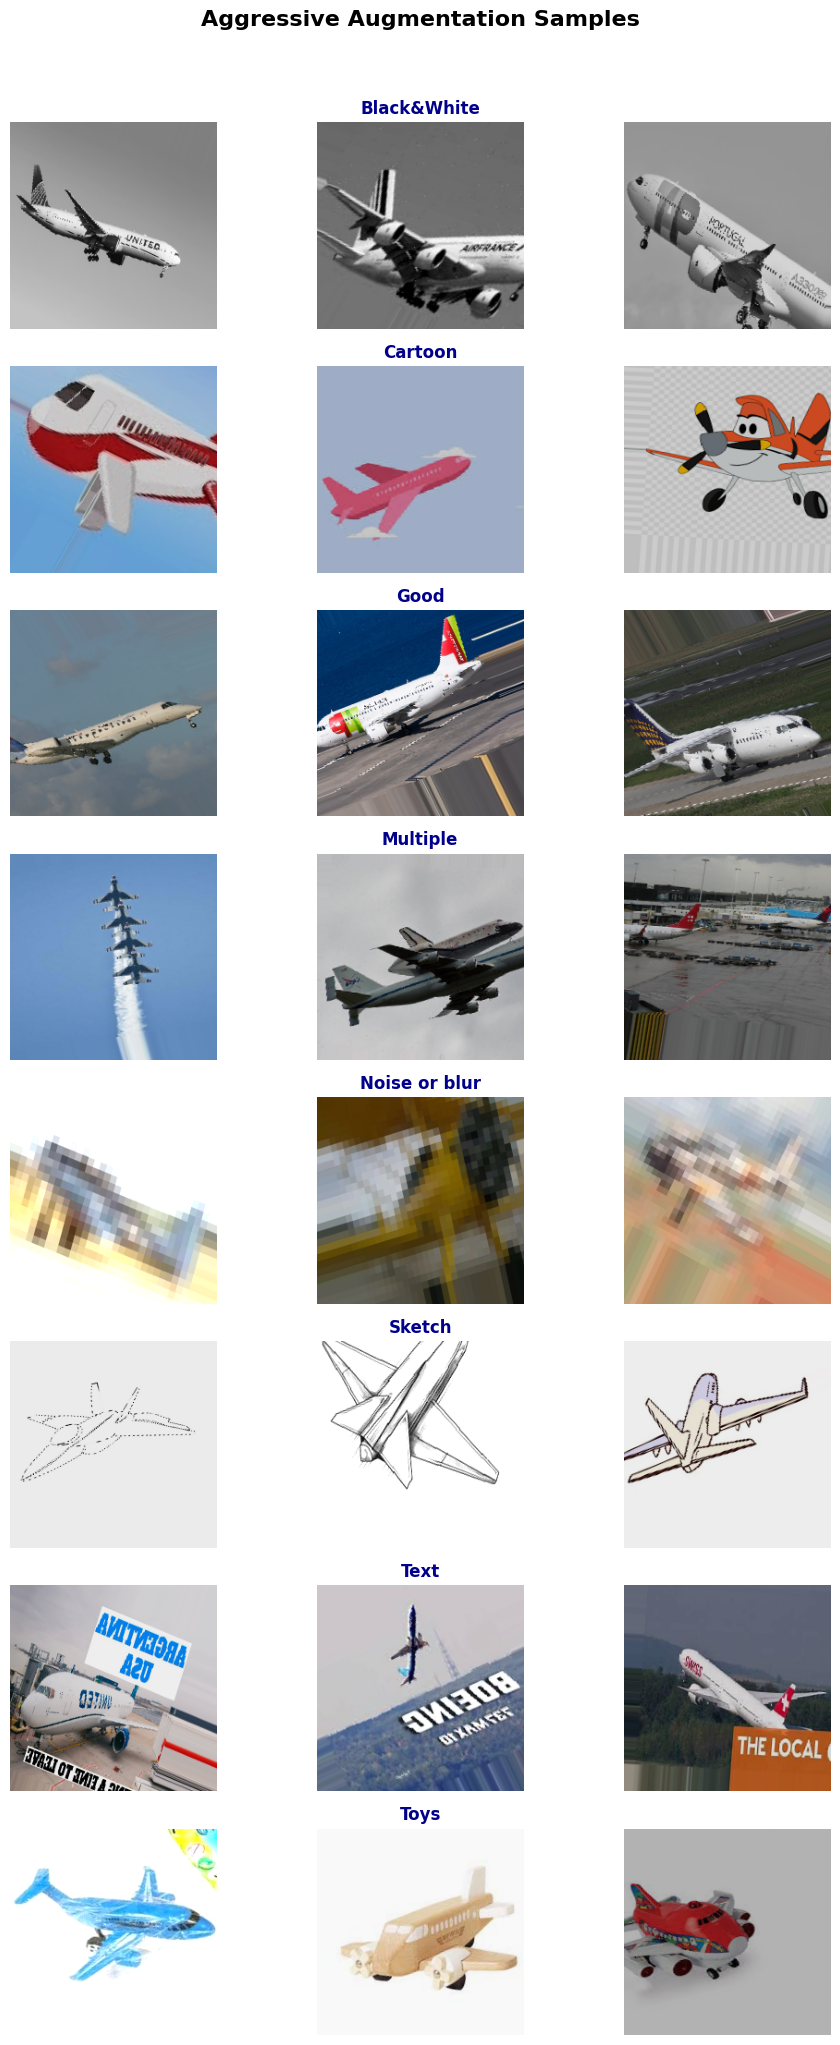

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

print("מגדיר אוגמנטציה אגרסיבית למניעת התאמת יתר (Overfitting)...\n")

# 1. הגדרת האוגמנטציה האגרסיבית
aggressive_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # סיבוב חזק יותר
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,        # עיוות זוויתי
    zoom_range=0.2,         # זום יותר משמעותי
    horizontal_flip=True,
    brightness_range=[0.7, 1.3], # משנה תאורה - קריטי!
    fill_mode='nearest'
)

# 2. יצירת גנרטורים חדשים (אימון ואימות משתמשים באותה אוגמנטציה!)
# ודא שהמשתנים TRAIN_DIR ו-VAL_DIR מוגדרים מתחילת המחברת
agg_train_gen = aggressive_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

agg_val_gen = aggressive_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

# 3. הצגת התמונות המעוותות (3 מכל מחלקה)
# מחלצים את שמות המחלקות והאינדקסים שלהן
class_labels = list(agg_train_gen.class_indices.keys())
images_per_class = 3
num_classes = len(class_labels)

print(f"\nמציג דוגמאות של אוגמנטציה ({images_per_class} מכל מחלקה):")

fig, axes = plt.subplots(num_classes, images_per_class, figsize=(10, 2.5 * num_classes))
fig.suptitle('Aggressive Augmentation Samples', fontsize=16, fontweight='bold', y=1.02)

# נמשוך batch מהגנרטור ונחפש תמונות לכל מחלקה
collected_counts = {i: 0 for i in range(num_classes)}
images_to_show = {i: [] for i in range(num_classes)}

# לולאה שרצה עד שמילאנו 3 תמונות מכל מחלקה
while any(count < images_per_class for count in collected_counts.values()):
    imgs, labels = next(agg_train_gen)
    for img, label in zip(imgs, labels):
        lbl_idx = int(label)
        if collected_counts[lbl_idx] < images_per_class:
            images_to_show[lbl_idx].append(img)
            collected_counts[lbl_idx] += 1

# ציור התמונות
for class_idx in range(num_classes):
    for j in range(images_per_class):
        ax = axes[class_idx, j]
        ax.imshow(images_to_show[class_idx][j])
        ax.axis('off')
        if j == 1: # כותרת רק באמצע השורה
            ax.set_title(class_labels[class_idx], fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

In [ ]:
import random
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# נתיבים
PREV_MODEL_PATH = "final_best_vgg16_combined_data.h5"
NEW_MODEL_PATH = "vgg16_AUG_LR_combined.h5"

print(f"Loading previous model: {PREV_MODEL_PATH}...")
# טעינת המודל הקודם
model = load_model(PREV_MODEL_PATH)

# --- פונקציית איחוד On The Fly ---
def combined_generator(train_gen, val_gen):
    p_train = len(train_gen) / (len(train_gen) + len(val_gen))
    while True:
        if random.random() < p_train:
            yield next(train_gen)
        else:
            yield next(val_gen)

total_steps_per_epoch = len(agg_train_gen) + len(agg_val_gen)

# --- Callbacks ---
# 1. שמירת מודל לפי דיוק (Accuracy) כי אין Validation
checkpoint_aug = ModelCheckpoint(
    NEW_MODEL_PATH,
    monitor='accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. מנגנון Reduce LR (הורדת קצב הלמידה אם המודל נתקע)
# מכיוון שאנחנו מאחדים נתונים ואין val_loss, נעקוב אחרי 'loss' רגיל!
reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,      # חותך בחצי
    patience=2,      # אם אחרי 2 אפוקים ה-loss לא יורד
    min_lr=1e-7,
    verbose=1
)

# --- הרצת האימון ---
EPOCHS_TO_RUN = 15 # נריץ 15 אפוקים על המודל החזק, רוב הסיכויים שהוא יתייצב לפני

print(f"\nStarting ON-THE-FLY training with AGGRESSIVE AUGMENTATION for {EPOCHS_TO_RUN} epochs...")

history_aug = model.fit(
    combined_generator(agg_train_gen, agg_val_gen),
    steps_per_epoch=total_steps_per_epoch,
    epochs=EPOCHS_TO_RUN,
    callbacks=[checkpoint_aug, reduce_lr]
)

print(f"\nFinished! The aggressively trained model is saved locally as: {NEW_MODEL_PATH}")

Loading previous model: final_best_vgg16_combined_data.h5...


2026-04-10 16:46:31.671839: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18629 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0



Starting ON-THE-FLY training with AGGRESSIVE AUGMENTATION for 15 epochs...
Epoch 1/15


2026-04-10 16:46:35.542461: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-04-10 16:46:38.037438: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-10 16:46:41.980938: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-10 16:46:42.718865: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fd7299a1a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-10 16:46:42.718895: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-04-10 16:46:42.725237: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 16:46:42.850347: I ./tensorflow/compiler/jit/device_compil

26/26 [==============================] - ETA: 0s - loss: 0.1181 - accuracy: 0.9519
Epoch 1: accuracy improved from -inf to 0.95192, saving model to vgg16_AUG_LR_combined.h5


/users/amit.cohen/.local/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


26/26 [==============================] - 24s 489ms/step - loss: 0.1181 - accuracy: 0.9519 - lr: 1.0000e-05
Epoch 2/15
26/26 [==============================] - ETA: 0s - loss: 0.1074 - accuracy: 0.9583
Epoch 2: accuracy improved from 0.95192 to 0.95833, saving model to vgg16_AUG_LR_combined.h5
26/26 [==============================] - 15s 581ms/step - loss: 0.1074 - accuracy: 0.9583 - lr: 1.0000e-05
Epoch 3/15
26/26 [==============================] - ETA: 0s - loss: 0.1087 - accuracy: 0.9650
Epoch 3: accuracy improved from 0.95833 to 0.96500, saving model to vgg16_AUG_LR_combined.h5
26/26 [==============================] - 12s 462ms/step - loss: 0.1087 - accuracy: 0.9650 - lr: 1.0000e-05
Epoch 4/15
26/26 [==============================] - ETA: 0s - loss: 0.1096 - accuracy: 0.9688
Epoch 4: accuracy improved from 0.96500 to 0.96875, saving model to vgg16_AUG_LR_combined.h5

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
26/26 [==============================] - 

מתחיל בהכנות להערכת המודל הסופי...

Loading the newly trained model: vgg16_AUG_LR_combined.h5...
Loading Test Images...
Found 144 images belonging to 8 classes.

נערך חיזוי סופי על סט הטסט...
5/5 [==============================] - 1s 138ms/step

דיוק סופי במבחן האמת (Test Accuracy): 91.67%

Classification Report:

               precision    recall  f1-score   support

  Black&White       0.94      0.83      0.88        18
      Cartoon       0.86      1.00      0.92        18
         Good       0.89      0.94      0.92        18
     Multiple       0.89      0.94      0.92        18
Noise or blur       1.00      1.00      1.00        18
       Sketch       0.89      0.89      0.89        18
         Text       0.89      0.89      0.89        18
         Toys       1.00      0.83      0.91        18

     accuracy                           0.92       144
    macro avg       0.92      0.92      0.92       144
 weighted avg       0.92      0.92      0.92       144


מצייר מטריצת בלבול..

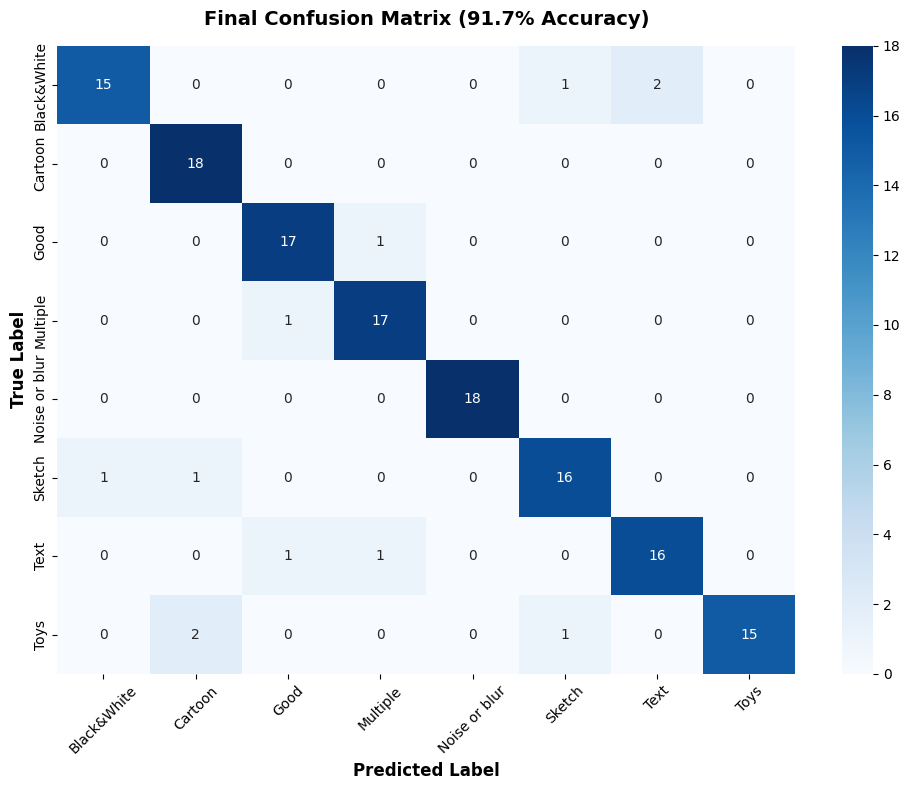

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("מתחיל בהכנות להערכת המודל הסופי...\n")

# 1. הגדרת נתיב המודל שאימנו הרגע
FINAL_MODEL_PATH = "vgg16_AUG_LR_combined.h5"

print(f"Loading the newly trained model: {FINAL_MODEL_PATH}...")
final_model = load_model(FINAL_MODEL_PATH)

# --- חשוב: יצירת גנרטור טסט נקי ---
# בניגוד לאימון שבו עשינו אוגמנטציה כבדה, בטסט אנחנו בוחנים את המודל על תמונות במצבן הטבעי (רק נרמול).
print("Loading Test Images...")
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen_clean = ImageDataGenerator(rescale=1./255)
clean_test_gen = test_datagen_clean.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False # קריטי שזה יהיה False כדי שהסדר של התוויות יתאים לתחזיות!
)

# חילוץ שמות המחלקות והתוויות האמיתיות
class_names = list(clean_test_gen.class_indices.keys())
y_true = clean_test_gen.classes

# 2. הרצת חיזוי על סט הטסט הנקי
print("\nנערך חיזוי סופי על סט הטסט...")
y_pred_prob = final_model.predict(clean_test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. הדפסת הדיוק הכללי (Accuracy)
accuracy = accuracy_score(y_true, y_pred)
print("\n" + "="*50)
print(f"דיוק סופי במבחן האמת (Test Accuracy): {accuracy * 100:.2f}%")
print("="*50 + "\n")

# 4. דוח סיווג טקסטואלי מפורט (Precision, Recall, F1)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. ציור מטריצת הבלבול (Confusion Matrix)
print("\nמצייר מטריצת בלבול...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title(f'Final Confusion Matrix ({accuracy*100:.1f}% Accuracy)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

מנתח 12 טעויות מסט המבחן ומציג וקטור Softmax מלא...



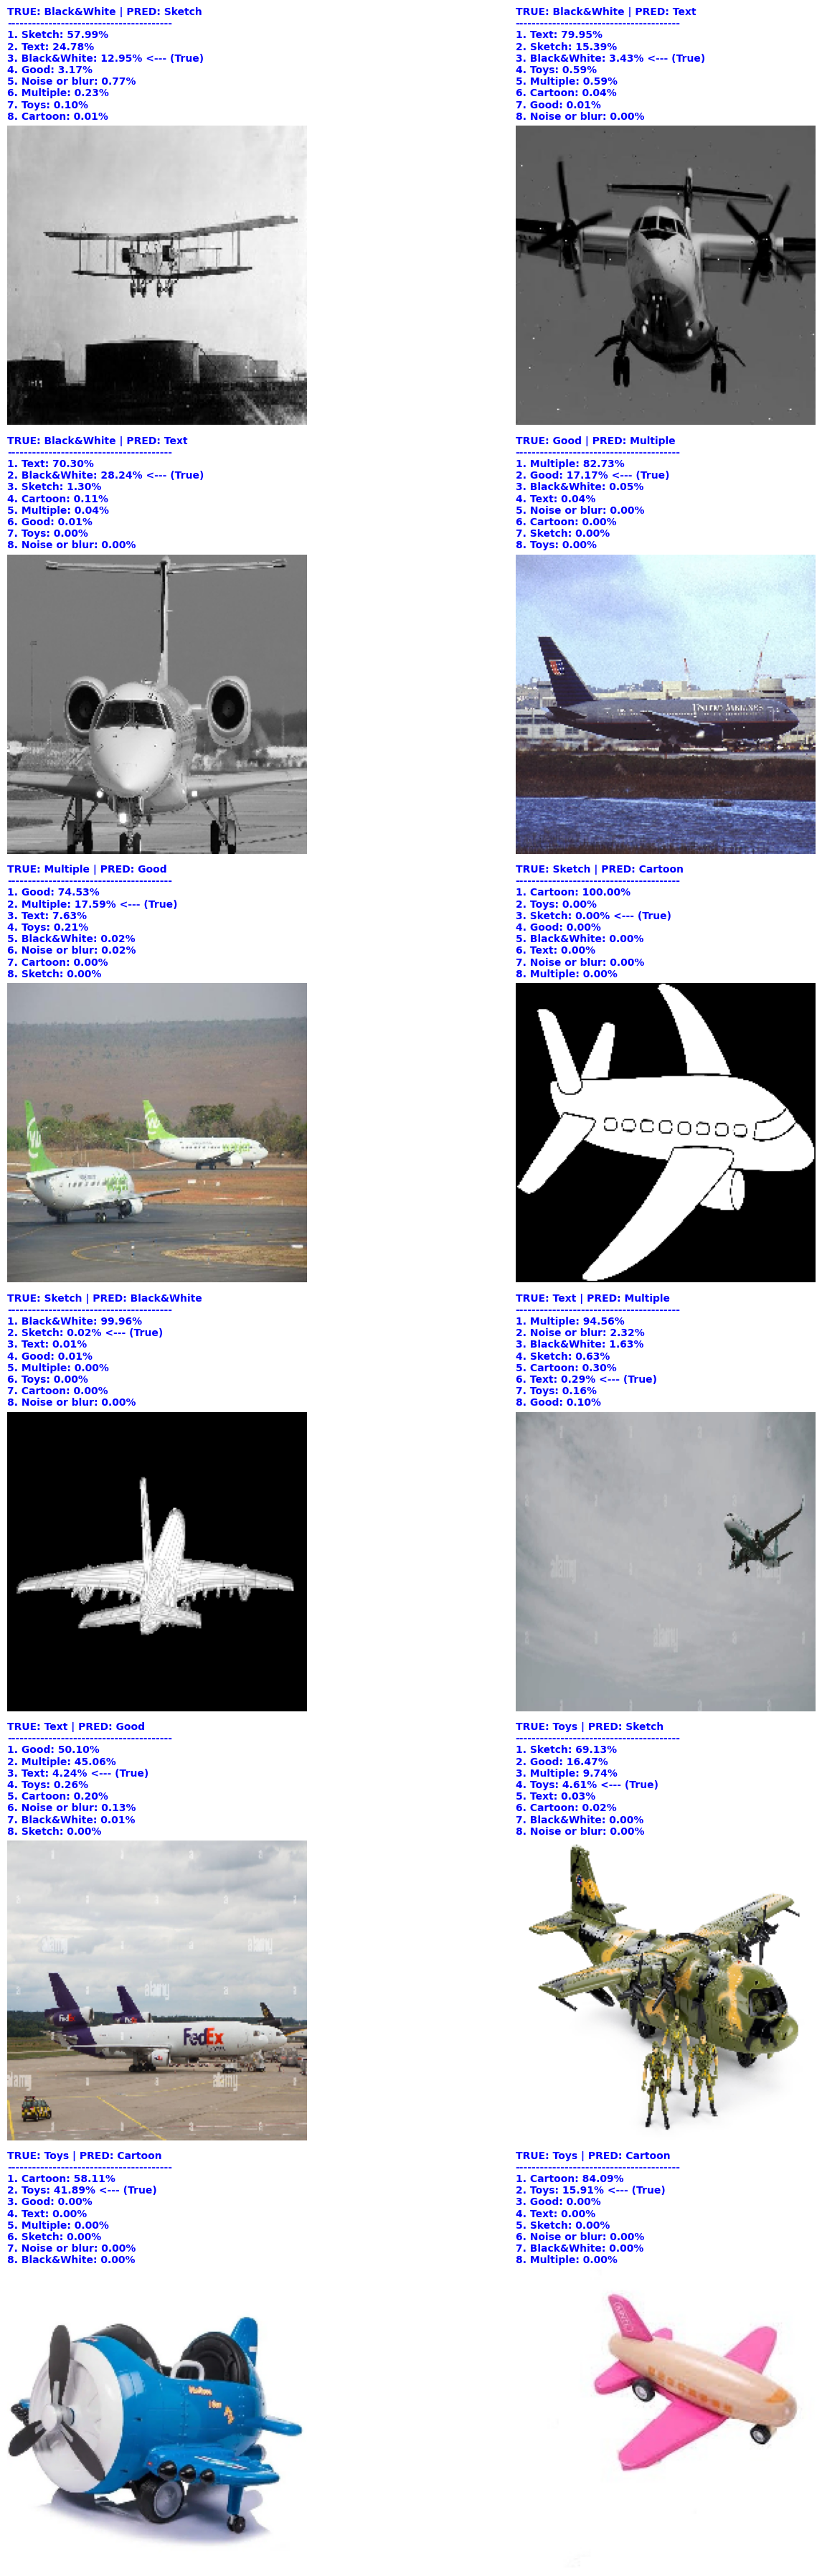

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import math

# מציאת כל האינדקסים של הטעויות בסט המבחן
incorrect_indices = np.where(y_pred != y_true)[0]

if len(incorrect_indices) == 0:
    print("אין טעויות להציג - המודל הגיע ל-100% דיוק!")
else:
    print(f"מנתח {len(incorrect_indices)} טעויות מסט המבחן ומציג וקטור Softmax מלא...\n")

    # נגדיר 2 עמודות כדי להשאיר מספיק מקום לטקסט הארוך של 8 המחלקות
    cols = 2
    rows = math.ceil(len(incorrect_indices) / cols)

    # חישוב גובה דינמי: כ-6 אינץ' לכל שורה כדי להכיל את כל הטקסט
    plt.figure(figsize=(16, 6 * rows))

    for i, idx in enumerate(incorrect_indices):
        # שליפת התמונה
        img_path = clean_test_gen.filepaths[idx]
        img = image.load_img(img_path, target_size=(224, 224))

        # שליפת התוויות
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        # חילוץ וקטור ה-Softmax השלם (כל 8 המחלקות)
        sample_probs = y_pred_prob[idx]

        # מיון כל 8 האינדקסים מהגבוה לנמוך
        sorted_indices = np.argsort(sample_probs)[::-1]

        # בניית טקסט התצוגה
        display_text = f"TRUE: {true_label} | PRED: {pred_label}\n"
        display_text += "-" * 40 + "\n"

        for rank, c_idx in enumerate(sorted_indices):
            c_name = class_names[c_idx]
            c_prob = sample_probs[c_idx] * 100
            # מדגישים את המחלקה האמיתית בחץ קטן כדי שיהיה קל למצוא אותה בתוך ה-8
            marker = " <--- (True)" if c_name == true_label else ""
            display_text += f"{rank+1}. {c_name}: {c_prob:.2f}%{marker}\n"

        # ציור התמונה
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(display_text.strip(), fontsize=10, color='blue', loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()